<a href="https://colab.research.google.com/github/NgocAnhNguyen-0601/-Crypto-Currency-Bitcoin-Price-Prediction-/blob/main/crypto_currency_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
plt.style.use('fivethirtyeight')

In [2]:
end = datetime.now()
start = datetime(end.year-15, end.month, end.day)
stock = 'BTC-USD'
stock_data = yf.download(stock, start = start, end = end)


/tmp/ipykernel_1073/1837361621.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock, start = start, end = end)
[*********************100%***********************]  1 of 1 completed


In [3]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


In [4]:
stock_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2026-05-26,75825.734375,77990.867188,75569.468750,77280.125000,35999475458
2026-05-27,74344.703125,76014.296875,74136.500000,75825.304688,33802172927
2026-05-28,73536.554688,74460.125000,72493.414062,74339.570312,40148145327
2026-05-29,73372.523438,74218.562500,72435.625000,73537.031250,34457929250
2026-05-30,73668.812500,73694.625000,73141.390625,73369.125000,30614716416


In [5]:
stock_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,4274.000000,4274.000000,4274.000000,4274.000000,4.274000e+03
mean,28582.963359,29132.024875,27966.786681,28566.840573,2.226753e+10
std,32433.341537,32974.510997,31843.197604,32429.505591,2.292782e+10
min,178.102997,211.731003,171.509995,176.897003,5.914570e+06
25%,3450.535889,3496.869629,3376.846008,3427.407043,1.664718e+09
50%,11518.089355,11803.060547,11248.950195,11505.770996,1.800522e+10
75%,46331.432617,47324.606445,44740.637695,46284.336914,3.441497e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


In [6]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4274 entries, 2014-09-17 to 2026-05-30
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   4274 non-null   float64
 1   (High, BTC-USD)    4274 non-null   float64
 2   (Low, BTC-USD)     4274 non-null   float64
 3   (Open, BTC-USD)    4274 non-null   float64
 4   (Volume, BTC-USD)  4274 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 200.3 KB


In [7]:
# Close Data Price
stock_data.columns
closing_price = stock_data[['Close']]
closing_price['Close']

Ticker,BTC-USD
Date,
2014-09-17,457.334015
2014-09-18,424.440002
2014-09-19,394.795990
2014-09-20,408.903992
2014-09-21,398.821014
...,...
2026-05-26,75825.734375
2026-05-27,74344.703125
2026-05-28,73536.554688


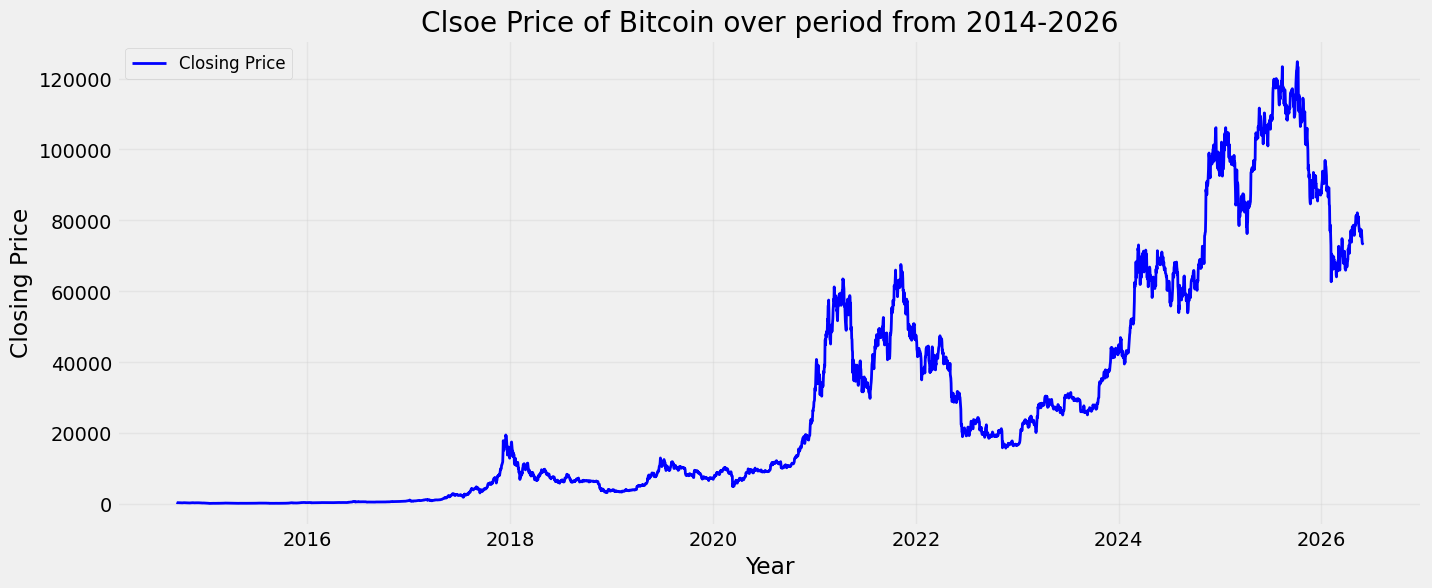

In [8]:
# Plot the closing price with trend:
plt.figure(figsize = (15,6))
plt.plot(closing_price.index, closing_price['Close'], label = 'Closing Price', color = 'Blue', linewidth = 2)
plt.title("Clsoe Price of Bitcoin over period from 2014-2026")
plt.xlabel("Year")
plt.ylabel("Closing Price")
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [9]:
# Moving Average:
temp_data = [10,20,30,40,50,60,70,80,90,100]
# Moving avergae for 5 day -> null null null null 30.0 40.0
print(sum(temp_data[0:5])/5)

30.0


In [10]:
df1 = pd.DataFrame(temp_data)

In [11]:
df1.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0
9,80.0


In [12]:
for i in range (2014, 2026):
  print(i, list(stock_data.index.year).count(i))

2014 106
2015 365
2016 366
2017 365
2018 365
2019 365
2020 366
2021 365
2022 365
2023 365
2024 366
2025 365


In [13]:
closing_price['MA_365'] = closing_price["Close"].rolling(window = 365).mean()
closing_price['MA_100'] = closing_price['Close'].rolling(window = 100).mean()

/tmp/ipykernel_1073/3538707382.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_365'] = closing_price["Close"].rolling(window = 365).mean()
/tmp/ipykernel_1073/3538707382.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_100'] = closing_price['Close'].rolling(window = 100).mean()


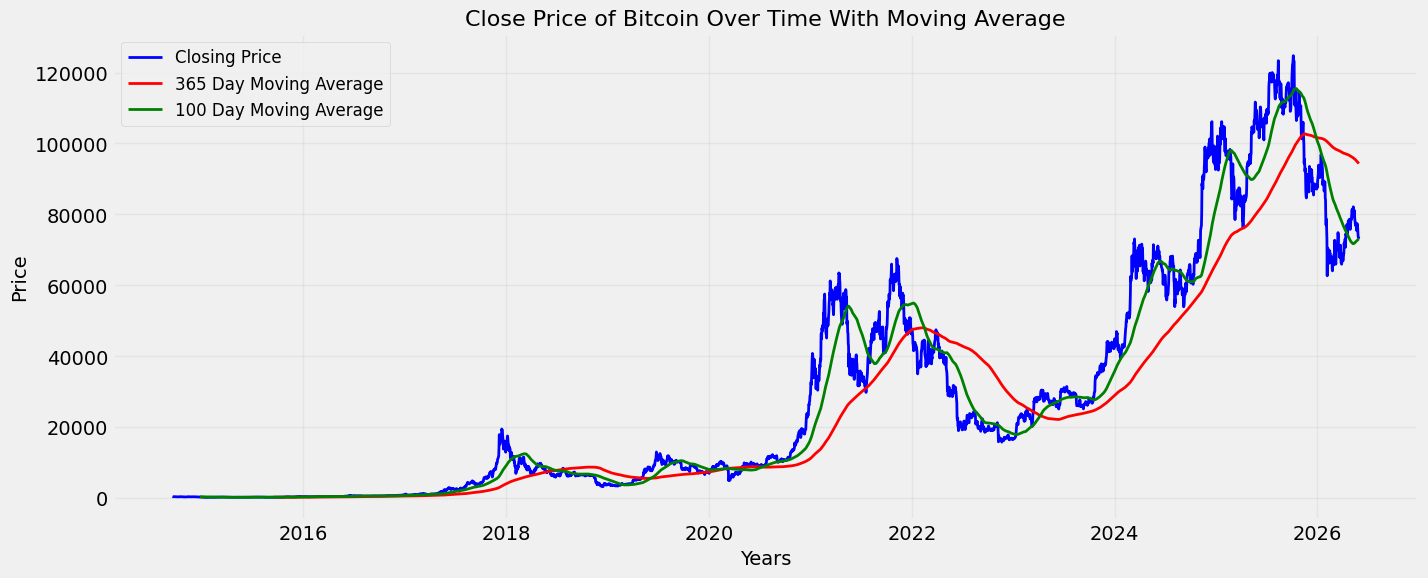

In [14]:
# PLot closing price with enhancement:
plt.figure(figsize = (15,6))
plt.plot(closing_price.index, closing_price['Close'], label = 'Closing Price', color = 'Blue', linewidth = 2)
plt.plot(closing_price.index, closing_price['MA_365'], label = '365 Day Moving Average', color = 'Red', linewidth = 2)
plt.plot(closing_price.index, closing_price['MA_100'], label = '100 Day Moving Average', color = 'Green', linewidth = 2)

plt.title("Close Price of Bitcoin Over Time With Moving Average", fontsize = 16 )
plt.xlabel("Years", fontsize = 14)
plt.ylabel("Price", fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()


LSTM - Long Short Term Memory

In [15]:
# Scale the data:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))
scaled_data = scaler.fit_transform(closing_price[['Close']].dropna())

In [16]:
scaled_data

array([[0.00224148],
       [0.00197743],
       [0.00173947],
       ...,
       [0.58887247],
       [0.58755574],
       [0.58993415]])

In [17]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [18]:
# Prepare Data for LSTM
x_data = []
y_data = []
base_days = 100
for i in range(base_days, len(scaled_data)):
  x_data.append(scaled_data[i-base_days:i])
  y_data.append(scaled_data[i])
x_data= np.array(x_data)
y_data=np.array(y_data)

In [20]:
# Splitting into train and test data:
train_size = int(len(x_data) * 0.9)
x_train, y_train = x_data[:train_size], y_data[:train_size]
x_test, y_test = x_data[train_size:], y_data[train_size:]

In [21]:
model = Sequential([
    LSTM(128, return_sequences = True, input_shape = (x_train.shape[1], 1)),
    LSTM(64, return_sequences = False),
    Dense(25),
    Dense(1)
])

model.compile(optimizer = 'adam', loss = "mean_squared_error")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,619 (459.45 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.fit(x_train, y_train, batch_size = 5, epochs = 10)

Epoch 1/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 8.2260e-04
Epoch 2/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 2.7880e-04
Epoch 3/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 2.2420e-04
Epoch 4/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 1.8520e-04
Epoch 5/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 1.7482e-04
Epoch 6/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 1.3953e-04
Epoch 7/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 1.8002e-04
Epoch 8/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 1.3131e-04
Epoch 9/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 1.2636e-04
Epoch 10/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 1.3120e-04


In [26]:
predictions = model.predict(x_test)
inv_predictions = scaler.inverse_transform(predictions)
inv_y_test = scaler.inverse_transform(y_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [27]:
inv_predictions

array([[ 78932.555],
       [ 75842.48 ],
       [ 82604.695],
       [ 79184.09 ],
       [ 83252.93 ],
       [ 85017.91 ],
       [ 83125.74 ],
       [ 84112.15 ],
       [ 83133.58 ],
       [ 83579.11 ],
       [ 84481.41 ],
       [ 83946.39 ],
       [ 84625.65 ],
       [ 84704.9  ],
       [ 87194.336],
       [ 93364.555],
       [ 93050.914],
       [ 93233.54 ],
       [ 94047.09 ],
       [ 93892.97 ],
       [ 92949.3  ],
       [ 94405.   ],
       [ 93537.805],
       [ 93549.54 ],
       [ 96068.62 ],
       [ 96268.875],
       [ 95108.44 ],
       [ 93526.445],
       [ 94203.484],
       [ 96415.13 ],
       [ 96425.24 ],
       [103205.36 ],
       [102063.14 ],
       [104003.02 ],
       [103097.84 ],
       [101776.09 ],
       [103494.2  ],
       [102609.19 ],
       [102955.93 ],
       [102656.94 ],
       [102381.88 ],
       [106051.57 ],
       [104616.1  ],
       [106087.6  ],
       [109118.13 ],
       [110875.5  ],
       [105648.61 ],
       [10700

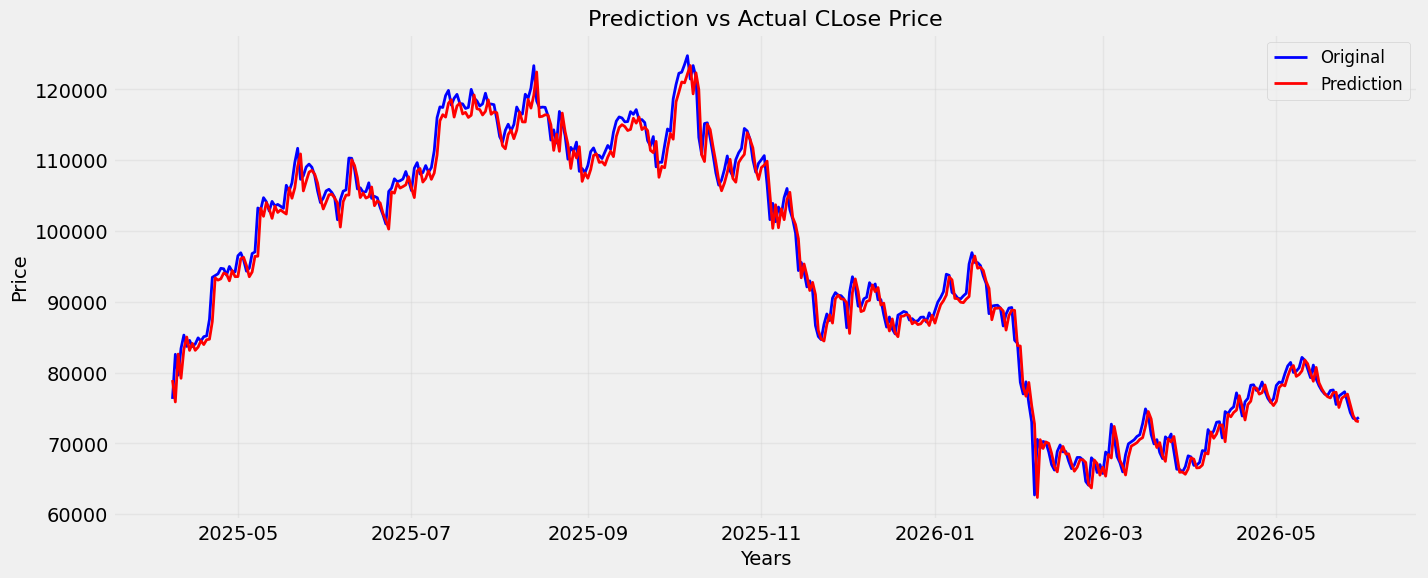

In [28]:
plotting_data = pd.DataFrame(
    {
        "Original": inv_y_test.flatten(),
        "Prediction": inv_predictions.flatten(),
    }, index = closing_price.index[train_size+base_days:]
)

plt.figure(figsize = (15,6))
plt.plot(plotting_data.index, plotting_data['Original'], label = 'Original', color = 'Blue', linewidth = 2)
plt.plot(plotting_data.index, plotting_data['Prediction'], label = 'Prediction', color = 'Red', linewidth = 2)

plt.title("Prediction vs Actual CLose Price", fontsize = 16 )
plt.xlabel("Years", fontsize = 14)
plt.ylabel("Price", fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()
